In [1]:
from google.colab import files

uploaded = files.upload()

Saving s-1-prepros-ASU.npz to s-1-prepros-ASU.npz
Saving s-2-prepros-ASU.npz to s-2-prepros-ASU.npz
Saving s-3-prepros-ASU.npz to s-3-prepros-ASU.npz
Saving s-4-prepros-ASU.npz to s-4-prepros-ASU.npz
Saving s-5-prepros-ASU.npz to s-5-prepros-ASU.npz
Saving s-6-prepros-ASU.npz to s-6-prepros-ASU.npz
Saving s-7-prepros-ASU.npz to s-7-prepros-ASU.npz
Saving s-8-prepros-ASU.npz to s-8-prepros-ASU.npz
Saving s-9-prepros-ASU.npz to s-9-prepros-ASU.npz
Saving s-10-prepros-ASU.npz to s-10-prepros-ASU.npz
Saving s-11-prepros-ASU.npz to s-11-prepros-ASU.npz
Saving s-12-prepros-ASU.npz to s-12-prepros-ASU.npz
Saving s-13-prepros-ASU.npz to s-13-prepros-ASU.npz
Saving s-14-prepros-ASU.npz to s-14-prepros-ASU.npz
Saving s-15-prepros-ASU.npz to s-15-prepros-ASU.npz
Saving s-16-prepros-ASU.npz to s-16-prepros-ASU.npz



Procesando sujeto 1
Variables disponibles: ['labels', 'hi', 'ha', 'ea', 'ev', 'eo', 'rl']
Forma original de data['hi']: (14, 24, 16, 240)
Forma final de X: (336, 16, 240)
Forma final de Y: (336,)

Procesando sujeto 2
Variables disponibles: ['labels', 'hi', 'ha', 'ea', 'ev', 'eo', 'rl']
Forma original de data['hi']: (14, 24, 16, 240)
Forma final de X: (336, 16, 240)
Forma final de Y: (336,)

Procesando sujeto 3
Variables disponibles: ['labels', 'hi', 'ha', 'ea', 'ev', 'eo', 'rl']
Forma original de data['hi']: (14, 24, 16, 240)
Forma final de X: (336, 16, 240)
Forma final de Y: (336,)

Procesando sujeto 4
Variables disponibles: ['labels', 'hi', 'ha', 'ea', 'ev', 'eo', 'rl']
Forma original de data['hi']: (14, 24, 16, 240)
Forma final de X: (336, 16, 240)
Forma final de Y: (336,)

Procesando sujeto 5
Variables disponibles: ['labels', 'hi', 'ha', 'ea', 'ev', 'eo', 'rl']
Forma original de data['hi']: (14, 30, 16, 240)
Forma final de X: (420, 16, 240)
Forma final de Y: (420,)

Procesando suj

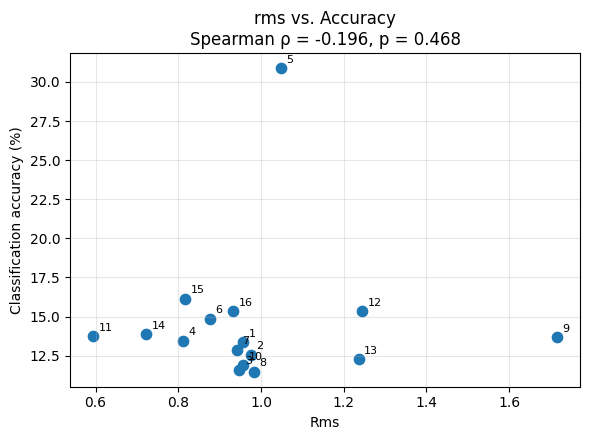

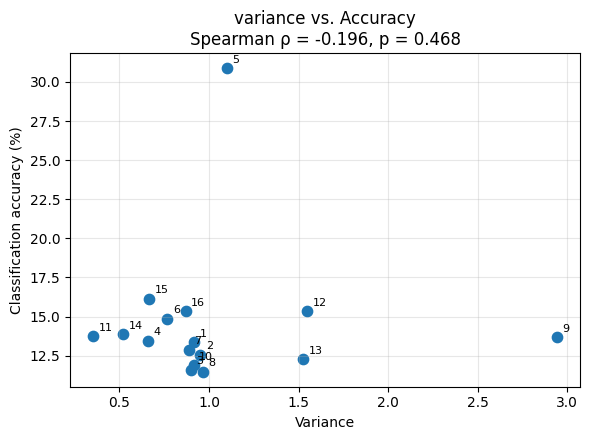

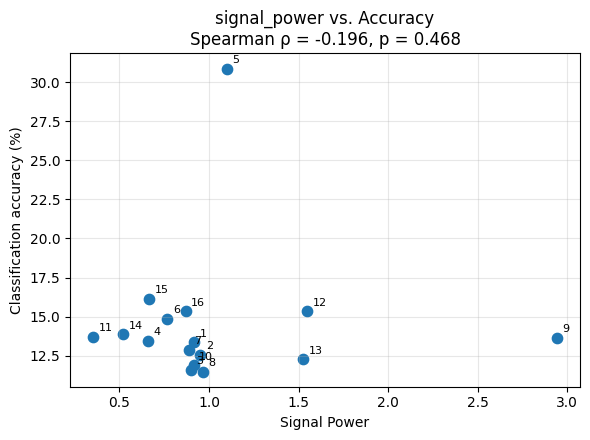

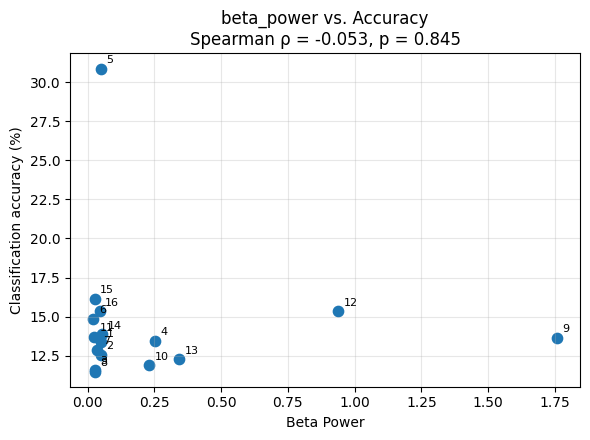


Análisis completado correctamente.


In [2]:
# -*- coding: utf-8 -*-
"""
Análisis de normalidad y correlación entre métricas EEG
y desempeño de clasificación por sujeto.

Created on Tue May 19 09:57:02 2026

@author: sigal
"""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import spearmanr, shapiro


# ======================================================
# CONFIGURACIÓN
# ======================================================

FS = 125
ALPHA = 0.05
NUMBER_OF_CLASSES = 14


# ======================================================
# SELECCIÓN DEL EXPERIMENTO
# ======================================================

def sel_exp(caso, data, labels):
    """
    Organiza los datos del experimento multiclase.

    Parameters
    ----------
    caso : str
        Tipo de experimento. Actualmente solo se admite "Multi".
    data : numpy.lib.npyio.NpzFile
        Archivo NPZ cargado.
    labels : ndarray
        Etiquetas almacenadas en el archivo.

    Returns
    -------
    X : ndarray
        Señales EEG organizadas por ensayo.
    Y : ndarray
        Etiquetas de clase.
    """

    class_dictionary = {
        "aceptar": 0,
        "cancelar": 1,
        "arriba": 2,
        "abajo": 3,
        "derecha": 4,
        "izquierda": 5,
        "hola": 6,
        "ayuda": 7,
        "gracias": 8,
        "a": 9,
        "e": 10,
        "i": 11,
        "o": 12,
        "u": 13
    }

    if caso != "Multi":
        raise ValueError('Solo está implementado el caso "Multi".')

    if "hi" not in data.files:
        raise KeyError('El archivo NPZ no contiene la variable "hi".')

    hi_data = data["hi"]

    print(f"Forma original de data['hi']: {hi_data.shape}")

    # Se asume que data["hi"] contiene una estructura:
    # clases × ensayos × canales × muestras
    X = np.vstack(hi_data)

    number_of_classes = len(class_dictionary)

    if hi_data.shape[0] != number_of_classes:
        print(
            f"Advertencia: se esperaban {number_of_classes} clases, "
            f"pero data['hi'] contiene {hi_data.shape[0]}."
        )

    # Se asume el mismo número de ensayos en cada clase
    trials_per_class = hi_data.shape[1]

    Y = np.repeat(
        np.arange(hi_data.shape[0]),
        trials_per_class
    )

    if len(X) != len(Y):
        raise ValueError(
            f"El número de ensayos de X ({len(X)}) no coincide "
            f"con el número de etiquetas Y ({len(Y)})."
        )

    return np.asarray(X, dtype=float), Y


# ======================================================
# MÉTRICAS DE CALIDAD DE LA SEÑAL
# ======================================================

def compute_rms(X):
    """
    Calcula el valor RMS global de las señales EEG.
    """

    X = np.asarray(X, dtype=float)

    return np.sqrt(np.mean(X**2))


def compute_variance(X):
    """
    Calcula la varianza global de las señales EEG.
    """

    X = np.asarray(X, dtype=float)

    return np.var(X)


def compute_signal_power(X):
    """
    Calcula la potencia media global de las señales EEG.
    """

    X = np.asarray(X, dtype=float)

    return np.mean(X**2)


def compute_beta_power(X, fs=125):
    """
    Calcula la potencia promedio en la banda beta, de 13 a 30 Hz.

    Se utiliza el método de Welch para estimar la densidad
    espectral de potencia y posteriormente se integra el área
    correspondiente a la banda beta.

    Parameters
    ----------
    X : ndarray
        Arreglo con dimensiones esperadas:
        ensayos × canales × muestras.
    fs : float
        Frecuencia de muestreo en Hz.

    Returns
    -------
    float
        Potencia beta promedio.
    """

    X = np.asarray(X, dtype=float)

    if X.ndim != 3:
        raise ValueError(
            "X debe tener tres dimensiones: "
            "ensayos × canales × muestras."
        )

    beta_powers = []

    for sample in X:

        for channel_signal in sample:

            channel_signal = np.asarray(
                channel_signal,
                dtype=float
            )

            if len(channel_signal) < 2:
                continue

            frequencies, psd = welch(
                channel_signal,
                fs=fs,
                nperseg=min(256, len(channel_signal))
            )

            beta_mask = (
                (frequencies >= 13)
                & (frequencies <= 30)
            )

            if np.count_nonzero(beta_mask) < 2:
                continue

            # Compatible con distintas versiones de NumPy
            if hasattr(np, "trapezoid"):
                beta_power = np.trapezoid(
                    psd[beta_mask],
                    frequencies[beta_mask]
                )
            else:
                beta_power = np.trapz(
                    psd[beta_mask],
                    frequencies[beta_mask]
                )

            beta_powers.append(beta_power)

    if len(beta_powers) == 0:
        return np.nan

    return float(np.mean(beta_powers))


# ======================================================
# EXACTITUD DE CLASIFICACIÓN POR SUJETO
# ======================================================

subject_accuracies = {
    1: 13.36633663,
    2: 12.57425756,
    3: 11.58415842,
    4: 13.46534672,
    5: 30.87301769,
    6: 14.85294085,
    7: 12.87128735,
    8: 11.48514833,
    9: 13.66336651,
    10: 11.88118801,
    11: 13.72727213,
    12: 15.34653454,
    13: 12.27722788,
    14: 13.86138630,
    15: 16.13861351,
    16: 15.34653454
}


# ======================================================
# ANÁLISIS POR SUJETO
# ======================================================

results = []

subjects = sorted(subject_accuracies.keys())

for subject_num in subjects:

    print("\n" + "=" * 60)
    print(f"Procesando sujeto {subject_num}")
    print("=" * 60)

    file_name = f"s-{subject_num}-prepros-ASU.npz"

    if not os.path.exists(file_name):
        raise FileNotFoundError(
            f"No se encontró el archivo: {file_name}"
        )

    with np.load(file_name, allow_pickle=True) as data:

        print(f"Variables disponibles: {data.files}")

        if "labels" not in data.files:
            raise KeyError(
                f'El archivo {file_name} no contiene "labels".'
            )

        labels = data["labels"]

        X, Y = sel_exp(
            caso="Multi",
            data=data,
            labels=labels
        )

    print(f"Forma final de X: {X.shape}")
    print(f"Forma final de Y: {Y.shape}")

    if X.ndim != 3:
        raise ValueError(
            f"Para el sujeto {subject_num}, X tiene forma {X.shape}. "
            "Se esperaba: ensayos × canales × muestras."
        )

    rms = compute_rms(X)
    variance = compute_variance(X)
    signal_power = compute_signal_power(X)
    beta_power = compute_beta_power(
        X,
        fs=FS
    )

    results.append({
        "subject": subject_num,
        "accuracy": subject_accuracies[subject_num],
        "rms": rms,
        "variance": variance,
        "signal_power": signal_power,
        "beta_power": beta_power
    })


# ======================================================
# CREACIÓN DEL DATAFRAME
# ======================================================

df = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("RESULTADOS POR SUJETO")
print("=" * 60)
print(df.to_string(index=False))


# ======================================================
# VERIFICACIÓN DE DATOS
# ======================================================

if df.isnull().values.any():
    print("\nAdvertencia: se encontraron valores NaN.")
    print(df.isnull().sum())

if np.isinf(
    df.select_dtypes(include=[np.number]).values
).any():
    raise ValueError(
        "Se encontraron valores infinitos en los resultados."
    )


# ======================================================
# MÉTRICAS ANALIZADAS
# ======================================================

metrics = [
    "rms",
    "variance",
    "signal_power",
    "beta_power"
]

variables = ["accuracy"] + metrics


# ======================================================
# PRUEBA DE NORMALIDAD SHAPIRO-WILK
# ======================================================

print("\n")
print("=" * 60)
print("SHAPIRO-WILK NORMALITY TEST")
print("=" * 60)

shapiro_results = []

for variable in variables:

    values = df[variable].dropna()

    if len(values) < 3:
        print(
            f"\n{variable}: no hay suficientes datos "
            "para aplicar Shapiro-Wilk."
        )
        continue

    statistic, p_value = shapiro(values)

    is_normal = p_value >= ALPHA

    shapiro_results.append({
        "variable": variable,
        "W": statistic,
        "p_value": p_value,
        "normality_rejected": not is_normal
    })

    print(f"\nVariable: {variable}")
    print(f"W statistic = {statistic:.6f}")
    print(f"p-value     = {p_value:.6f}")

    if is_normal:
        print(
            f"Resultado: no se rechaza la normalidad "
            f"(p >= {ALPHA})."
        )
    else:
        print(
            f"Resultado: se rechaza la normalidad "
            f"(p < {ALPHA})."
        )


shapiro_df = pd.DataFrame(shapiro_results)


# ======================================================
# CORRELACIÓN DE SPEARMAN
# ======================================================

print("\n")
print("=" * 60)
print("SPEARMAN RANK CORRELATION")
print("=" * 60)

spearman_results = []

for metric in metrics:

    valid_data = df[
        [metric, "accuracy"]
    ].dropna()

    if len(valid_data) < 3:
        print(
            f"\n{metric}: no hay suficientes datos "
            "para calcular la correlación."
        )
        continue

    rho, p_value = spearmanr(
        valid_data[metric],
        valid_data["accuracy"]
    )

    significant = p_value < ALPHA

    spearman_results.append({
        "metric": metric,
        "rho": rho,
        "p_value": p_value,
        "significant": significant
    })

    print(f"\nMétrica: {metric}")
    print(f"Spearman rho = {rho:.6f}")
    print(f"p-value      = {p_value:.6f}")

    if significant:
        print(
            f"Resultado: correlación estadísticamente "
            f"significativa (p < {ALPHA})."
        )
    else:
        print(
            f"Resultado: correlación no estadísticamente "
            f"significativa (p >= {ALPHA})."
        )


spearman_df = pd.DataFrame(spearman_results)


# ======================================================
# GUARDAR RESULTADOS
# ======================================================

df.to_csv(
    "eeg_metrics_by_subject.csv",
    index=False
)

shapiro_df.to_csv(
    "shapiro_wilk_results.csv",
    index=False
)

spearman_df.to_csv(
    "spearman_correlation_results.csv",
    index=False
)

print("\n")
print("=" * 60)
print("ARCHIVOS GENERADOS")
print("=" * 60)
print("1. eeg_metrics_by_subject.csv")
print("2. shapiro_wilk_results.csv")
print("3. spearman_correlation_results.csv")


# ======================================================
# GRÁFICAS DE DISPERSIÓN
# ======================================================

for metric in metrics:

    valid_data = df[
        [metric, "accuracy"]
    ].dropna()

    plt.figure(figsize=(6, 4.5))

    plt.scatter(
        valid_data[metric],
        valid_data["accuracy"],
        s=55
    )

    # Etiqueta del número de sujeto
    for index in valid_data.index:

        plt.annotate(
            str(int(df.loc[index, "subject"])),
            (
                df.loc[index, metric],
                df.loc[index, "accuracy"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    correlation_row = spearman_df[
        spearman_df["metric"] == metric
    ]

    if not correlation_row.empty:

        rho = correlation_row.iloc[0]["rho"]
        p_value = correlation_row.iloc[0]["p_value"]

        title = (
            f"{metric} vs. Accuracy\n"
            f"Spearman ρ = {rho:.3f}, p = {p_value:.3f}"
        )

    else:
        title = f"{metric} vs. Accuracy"

    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("Classification accuracy (%)")
    plt.title(title)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    figure_name = (
        f"{metric}_vs_accuracy.png"
    )

    plt.savefig(
        figure_name,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


print("\nAnálisis completado correctamente.")